# 02 — Preprocessing 

**Goal:** Clean raw vibration signals, apply Butterworth filtering, segment into windows, and save a processed dataset ready for feature extraction.


---
### What this notebook covers
1. Setup & imports  
2. Load raw signals  
3. Step-by-step preprocessing visualization (DC removal → filter — NO normalize)  
4. Filter verification in frequency domain  
5. Global amplitude statistics — confirm energy differences preserved  
6. Apply pipeline to all signals  
7. Signal windowing (segmentation)  
8. Window-level class distribution  
9. Train/test split (stratified)  
10. Save processed dataset  
11. Preprocessing summary  

---
## 1. Setup & Imports

In [2]:
import sys
import os

sys.path.append(os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.fft import rfft, rfftfreq
from scipy.signal import welch
from collections import Counter
from sklearn.model_selection import train_test_split

from loader import build_dataset, get_label_name
from filters import (
    remove_dc_offset,
    butterworth_lowpass,
    segment_signal,
)

print('✓ All imports successful')

✓ All imports successful


In [3]:
plt.rcParams['figure.dpi'] =120
plt.rcParams['figure.facecolor'] = '#0f0f11'
plt.rcParams['axes.facecolor']= '#0f0f11'
plt.rcParams['axes.edgecolor']   = '#2a2a30'
plt.rcParams['axes.labelcolor'] = '#ccccdd'
plt.rcParams['xtick.color'] = '#7a7a8e'
plt.rcParams['ytick.color'] = '#7a7a8e'
plt.rcParams['text.color']= '#e8e8f0'
plt.rcParams['grid.color']= '#1e2330'
plt.rcParams['grid.linewidth']=0.6

CLASS_COLORS = {
    0: '#4fbe97',   # Normal — green
    1: '#3d6aff',   # Inner Race — blue
    2: '#f0a147',   # Ball — orange
    3: '#c17cff',   # Outer Race — purple
}
CLASS_NAMES = {0: 'Normal', 1: 'Inner Race', 2: 'Ball', 3: 'Outer Race'}

In [4]:

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
REPORTS_DIR = os.path.join(PROJECT_ROOT, 'reports')

FS=12000   
WINDOW_SIZE= 1024     
OVERLAP= 0.5      
CUTOFF_HZ= 5000.0   
FILTER_ORDER = 5        
TEST_SIZE= 0.2      
RANDOM_SEED= 42

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR,   exist_ok=True)

print('── Configuration ────────────────────────────────────')
print(f'  Window size   : {WINDOW_SIZE} samples  ({WINDOW_SIZE/FS*1000:.1f} ms)')
print(f'  Overlap       : {int(OVERLAP*100)}%  →  step = {int(WINDOW_SIZE*(1-OVERLAP))} samples')
print(f'  Cutoff freq   : {CUTOFF_HZ:.0f} Hz')
print(f'  Filter order  : {FILTER_ORDER}')
print(f'  Train/test    : {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}  (stratified)')


── Configuration ────────────────────────────────────
  Window size   : 1024 samples  (85.3 ms)
  Overlap       : 50%  →  step = 512 samples
  Cutoff freq   : 5000 Hz
  Filter order  : 5
  Train/test    : 80/20  (stratified)


---
## 2. Load Raw Signals

In [5]:
records = build_dataset(DATA_DIR)

EXCLUDE_FILES = ['OR_014_1.mat']   # near-zero fault energy, indistinguishable from Normal
records = [r for r in records if r['file'] not in EXCLUDE_FILES]

print(f'Files after exclusion: {len(records)}')
for r in records:
    print(f"  [{r['label']}] {r['file']}")

print(f'\n── Loaded Files ─────────────────────────────────────')
print(f'  {"Label":<4}  {"Class":<12}  {"File":<25}  {"Samples":>10}  {"Duration":>9}')
print('  ' + '─' * 68)
for r in records:
    duration = len(r['signal']) / FS
    print(f"  [{r['label']}]   {get_label_name(r['label']):<12}  "
          f"{r['file']:<25}  {len(r['signal']):>10,}  {duration:>8.1f}s")




✓ Loaded 12 files successfully.
Files after exclusion: 11
  [1] IR_007_1.mat
  [1] IR_014_1.mat
  [1] IR_021_1.mat
  [1] IR_028_1.mat
  [3] OR_007_1.mat
  [3] OR_021_1.mat
  [2] ball_007_1.mat
  [2] ball_014_1.mat
  [2] ball_021_1.mat
  [2] ball_028_1.mat
  [0] normal_1.mat

── Loaded Files ─────────────────────────────────────
  Label  Class         File                          Samples   Duration
  ────────────────────────────────────────────────────────────────────
  [1]   Inner Race    IR_007_1.mat                  121,991      10.2s
  [1]   Inner Race    IR_014_1.mat                  121,846      10.2s
  [1]   Inner Race    IR_021_1.mat                  121,556      10.1s
  [1]   Inner Race    IR_028_1.mat                  121,351      10.1s
  [3]   Outer Race    OR_007_1.mat                  122,426      10.2s
  [3]   Outer Race    OR_021_1.mat                  121,991      10.2s
  [2]   Ball          ball_007_1.mat                121,410      10.1s
  [2]   Ball          ball_01

---
## 3. Step-by-Step Preprocessing Visualization

Pipeline applied: **DC removal → Butterworth low-pass filter**  


In [6]:
demo_rec = next((r for r in records if r['label'] == 3), records[0])
raw= demo_rec['signal']

print(f'Demo signal   : {demo_rec["file"]}')
print(f'Class         : {get_label_name(demo_rec["label"])}')
print(f'Total samples : {len(raw):,}')
print(f'DC offset     : {np.mean(raw):.6f}  (should be near 0 for CWRU data)')
print(f'RMS (raw)     : {np.sqrt(np.mean(raw**2)):.6f}')
print(f'Peak (raw)    : {np.max(np.abs(raw)):.6f}')

Demo signal   : OR_007_1.mat
Class         : Outer Race
Total samples : 122,426
DC offset     : 0.004061  (should be near 0 for CWRU data)
RMS (raw)     : 0.591947
Peak (raw)    : 3.112257


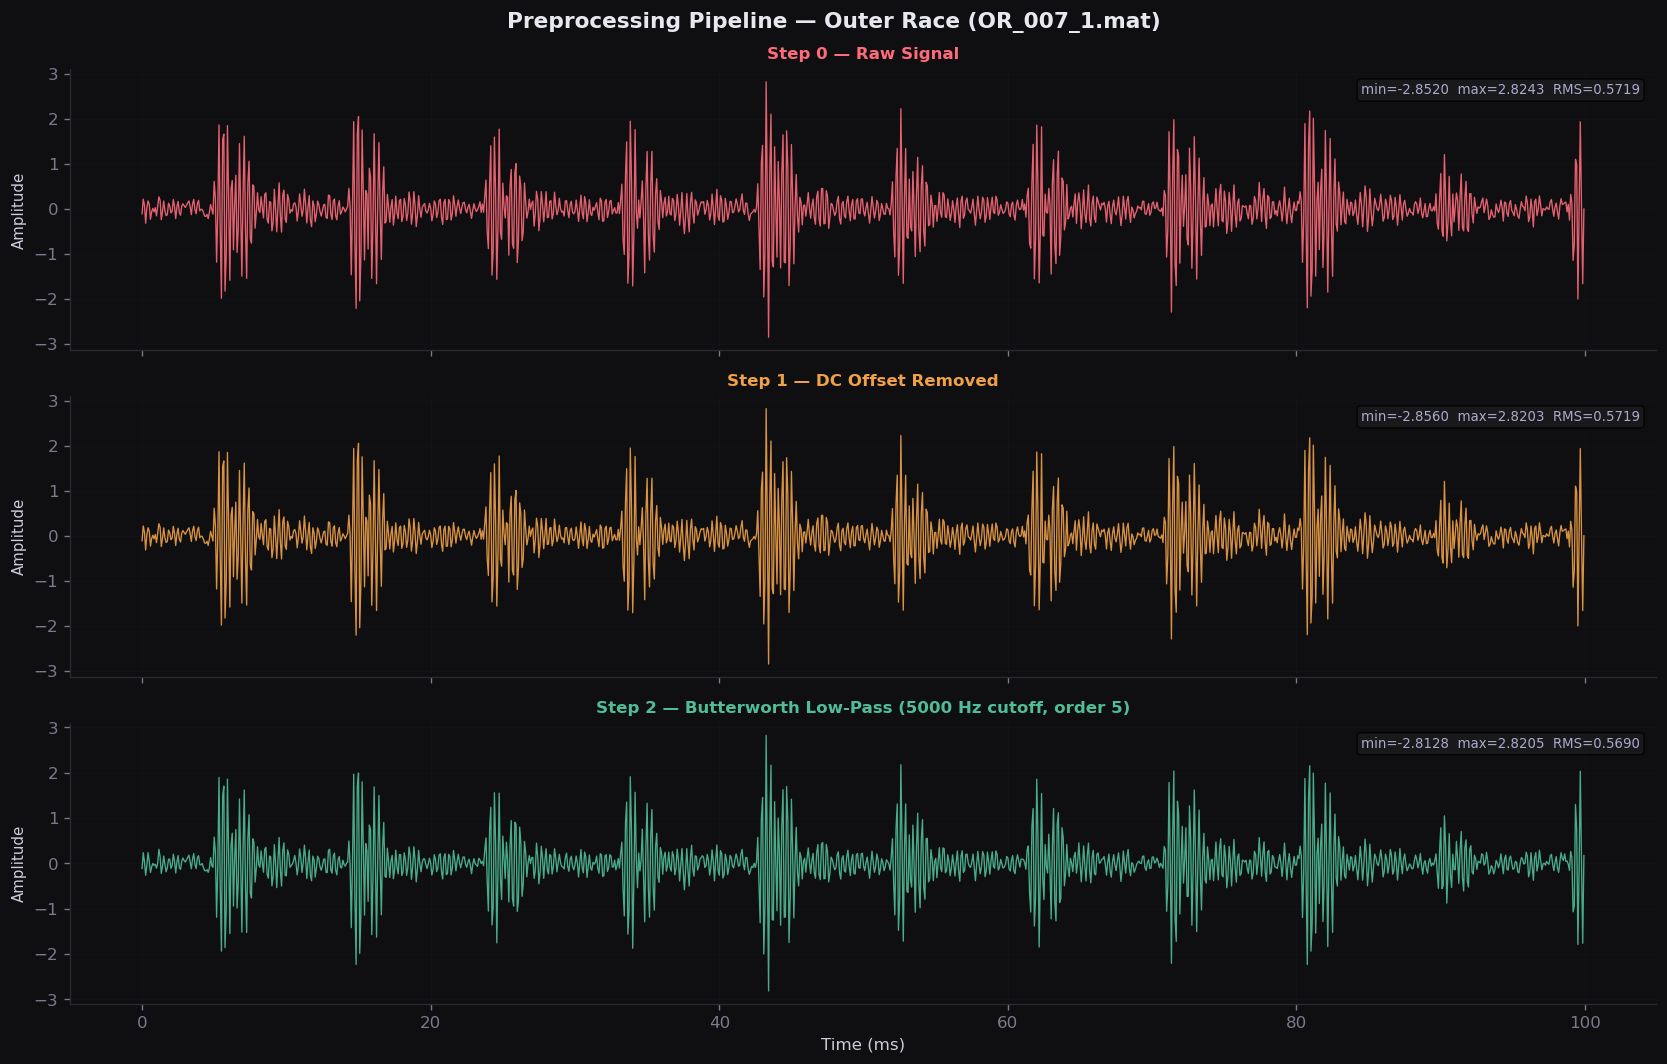

Saved → reports/08_preprocessing_steps.png


In [7]:
step1_dc = remove_dc_offset(raw)
step2_filter = butterworth_lowpass(step1_dc, cutoff_hz=CUTOFF_HZ, fs=FS, order=FILTER_ORDER)


N_PLOT = int(FS * 0.1)   # 100 ms
t= np.arange(N_PLOT) / FS *1000

steps = [
    (raw[:N_PLOT],'#ff6b7a', 'Step 0 — Raw Signal'),
    (step1_dc[:N_PLOT], '#f0a147', 'Step 1 — DC Offset Removed'),
    (step2_filter[:N_PLOT], '#4fbe97', f'Step 2 — Butterworth Low-Pass ({CUTOFF_HZ:.0f} Hz cutoff, order {FILTER_ORDER})'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle(f'Preprocessing Pipeline — {get_label_name(demo_rec["label"])} ({demo_rec["file"]})',
             fontsize=13, fontweight='bold')

for ax, (sig, color, title) in zip(axes, steps):
    ax.plot(t, sig, color=color, linewidth=0.8, alpha=0.9)
    ax.set_title(title, fontsize=10, fontweight='bold', color=color)
    ax.set_ylabel('Amplitude', fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

    rms_val = np.sqrt(np.mean(sig**2))
    ax.text(0.99, 0.95,
            f'min={sig.min():.4f}  max={sig.max():.4f}  RMS={rms_val:.4f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='#aaaacc',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1e1e22', alpha=0.7))

axes[-1].set_xlabel('Time (ms)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '08_preprocessing_steps.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/08_preprocessing_steps.png')



---
## 4. Filter Verification — Frequency Domain

Confirm the filter removes noise above 5000 Hz without touching fault-characteristic frequencies (3400–3600 Hz).



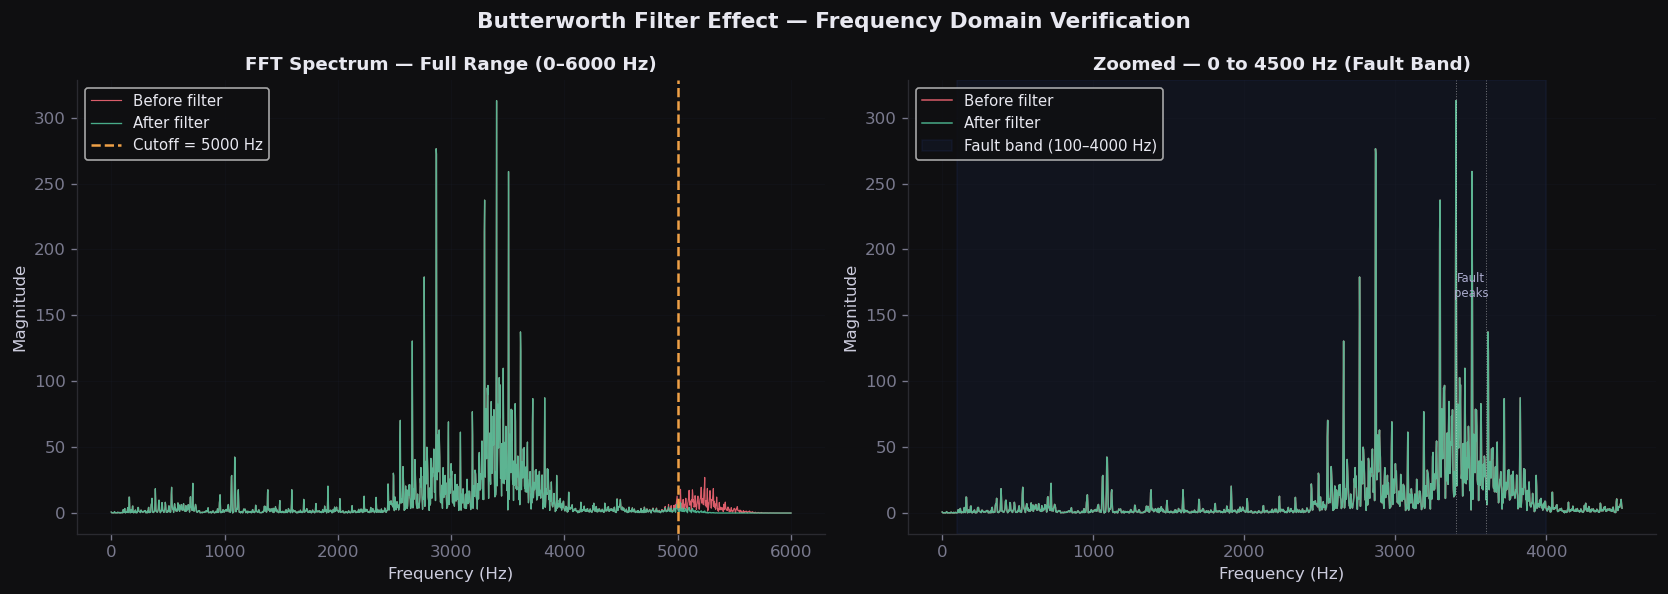

Saved → reports/09_filter_frequency_effect.png


In [8]:
N_FFT= 4096
hann = np.hanning(N_FFT)           #Hanning window prevents spectral leakage

seg_raw =step1_dc[:N_FFT]*hann    #apply window before FFT
seg_filt = step2_filter[:N_FFT] *hann

freqs= rfftfreq(N_FFT, d=1.0 /FS)
fft_raw =np.abs(rfft(seg_raw))
fft_filt= np.abs(rfft(seg_filt))

fig,axes = plt.subplots(1,2, figsize=(14, 5))


axes[0].plot(freqs, fft_raw,  color='#ff6b7a', linewidth=0.7,
             alpha=0.85, label='Before filter')
axes[0].plot(freqs, fft_filt, color='#4fbe97', linewidth=0.8,
             alpha=0.9,  label='After filter')
axes[0].axvline(CUTOFF_HZ, color='#f0a147', linewidth=1.5,
                linestyle='--', label=f'Cutoff = {CUTOFF_HZ:.0f} Hz')
axes[0].set_title('FFT Spectrum — Full Range (0–6000 Hz)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Zoomed into fault band ────────────────────────────────────────────
mask = freqs <= 4500
axes[1].plot(freqs[mask], fft_raw[mask],  color='#ff6b7a',
             linewidth=0.9, alpha=0.85, label='Before filter')
axes[1].plot(freqs[mask], fft_filt[mask], color='#4fbe97',
             linewidth=0.9, alpha=0.9,  label='After filter')
axes[1].axvspan(100,  4000, color='#3d6aff', alpha=0.06, label='Fault band (100–4000 Hz)')
axes[1].axvline(3400, color='#ffffff', linewidth=0.6, linestyle=':', alpha=0.4)
axes[1].axvline(3600, color='#ffffff', linewidth=0.6, linestyle=':', alpha=0.4)
axes[1].text(3500, axes[1].get_ylim()[1] * 0.5, 'Fault\npeaks',
             ha='center', fontsize=7, color='#aaaacc')
axes[1].set_title('Zoomed — 0 to 4500 Hz (Fault Band)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('Butterworth Filter Effect — Frequency Domain Verification',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '09_filter_frequency_effect.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/09_filter_frequency_effect.png')



---
## 5. Global Amplitude Statistics — Confirm Energy Differences Are Preserved


In [9]:
print('── Per-File Amplitude Statistics After Filtering ────────────────────────────────')
print(f'  {"File":<25}  {"Class":<12}  {"RMS":>8}  {"Peak":>8}  {"Std":>8}  {"Mean DC":>10}')
print('  ' + '─' * 80)

stats_after = []
for r in records:
    sig_clean =butterworth_lowpass(
        remove_dc_offset(r['signal']),
        cutoff_hz=CUTOFF_HZ, fs=FS, order=FILTER_ORDER
    )
    rms  = np.sqrt(np.mean(sig_clean**2))
    peak = np.max(np.abs(sig_clean))
    std  = np.std(sig_clean)
    dc   = np.mean(sig_clean)
    stats_after.append({
        'file': r['file'], 'label': r['label'],
        'class': get_label_name(r['label']),
        'rms': rms, 'peak': peak, 'std': std, 'dc': dc
    })
    flag = ''
    if r['file'] in ['OR_014_1.mat', 'IR_028_1.mat', 'ball_028_1.mat']:
        flag = '  ⚠'
    print(f"  {r['file']:<25}  {get_label_name(r['label']):<12}  "
          f"{rms:>8.4f}  {peak:>8.4f}  {std:>8.4f}  {dc:>10.6f}{flag}")

print()
print('── Mean RMS per Class (energy preserved after filtering) ────────────────────────')
df_stats = pd.DataFrame(stats_after)
class_rms = df_stats.groupby('class')['rms'].agg(['mean', 'min', 'max']).round(4)
print(class_rms.to_string())


── Per-File Amplitude Statistics After Filtering ────────────────────────────────
  File                       Class              RMS      Peak       Std     Mean DC
  ────────────────────────────────────────────────────────────────────────────────
  IR_007_1.mat               Inner Race      0.2926    1.5591    0.2926    0.000000
  IR_014_1.mat               Inner Race      0.1652    2.0349    0.1652    0.000000
  IR_021_1.mat               Inner Race      0.4417    3.6191    0.4417   -0.000000
  IR_028_1.mat               Inner Race      0.8374    3.9253    0.8374   -0.000000  ⚠
  OR_007_1.mat               Outer Race      0.5884    3.1147    0.5884    0.000000
  OR_021_1.mat               Outer Race      0.5611    6.2057    0.5611   -0.000000
  ball_007_1.mat             Ball            0.1390    0.6663    0.1390    0.000000
  ball_014_1.mat             Ball            0.1407    1.3206    0.1407   -0.000000
  ball_021_1.mat             Ball            0.1284    1.4704    0.1284    0

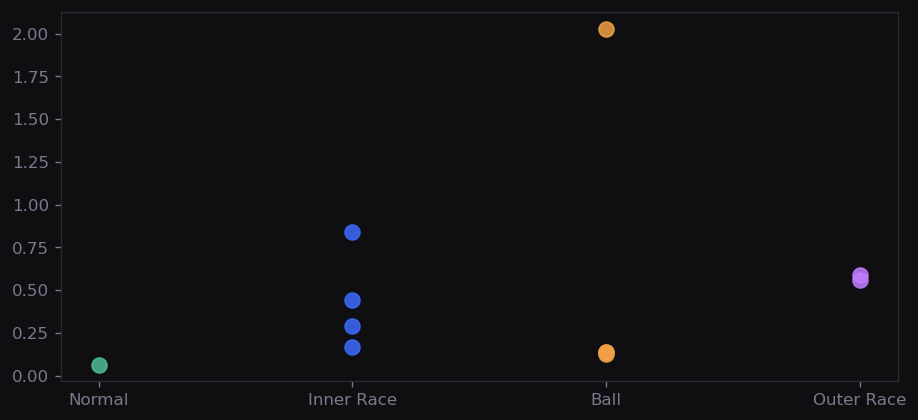

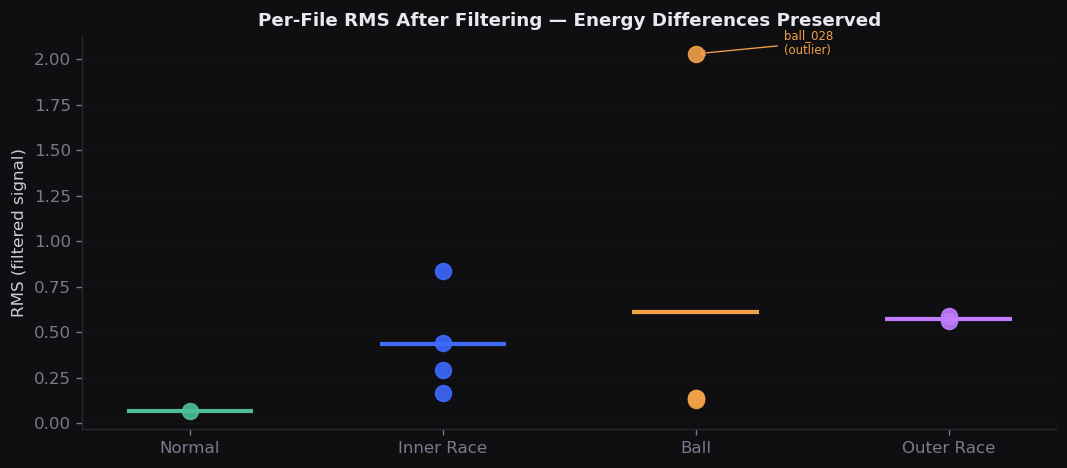

Saved → reports/09b_rms_per_class_after_filter.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

class_order= [0, 1, 2, 3]
for label in class_order:
    subset = df_stats[df_stats['label'] == label]
    ax.scatter(
        [get_label_name(label)] * len(subset),
        subset['rms'],
        color=CLASS_COLORS[label],
        s=80, zorder=3, alpha=0.85
    )
    mean_rms = subset['rms'].mean()
    ax.hlines(mean_rms,
              xmin=get_label_name(label), xmax=get_label_name(label),
              linewidth=0, zorder=2)

fig, ax = plt.subplots(figsize=(9, 4))
positions = {0: 0, 1: 1, 2: 2, 3: 3}
for label in class_order:
    subset = df_stats[df_stats['label'] == label]
    jitter = np.zeros(len(subset))
    ax.scatter(
        [positions[label]] * len(subset) + jitter,
        subset['rms'].values,
        color=CLASS_COLORS[label], s=90, zorder=3, alpha=0.9,
        label=get_label_name(label)
    )
    mean_rms = subset['rms'].mean()
    ax.hlines(mean_rms, positions[label] - 0.25, positions[label] + 0.25,
              color=CLASS_COLORS[label], linewidth=2.5, zorder=4)

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['Normal', 'Inner Race', 'Ball', 'Outer Race'])
ax.set_ylabel('RMS (filtered signal)')
ax.set_title('Per-File RMS After Filtering — Energy Differences Preserved',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

anomalous = {'OR_014_1.mat': 'OR_014\n(anomalous)',
             'ball_028_1.mat': 'ball_028\n(outlier)'}
for row in stats_after:
    if row['file'] in anomalous:
        ax.annotate(anomalous[row['file']],
                    xy=(positions[row['label']], row['rms']),
                    xytext=(positions[row['label']] + 0.35, row['rms']),
                    fontsize=7, color='#f0a147',
                    arrowprops=dict(arrowstyle='->', color='#f0a147', lw=0.8))

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '09b_rms_per_class_after_filter.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/09b_rms_per_class_after_filter.png')

---
## 6. Apply Full Pipeline to All Signals

Pipeline: **DC removal → Butterworth low-pass filter**  


In [11]:
print(f'  Steps: DC removal → Butterworth low-pass ({CUTOFF_HZ:.0f} Hz, order {FILTER_ORDER})')

for rec in records:
    sig = remove_dc_offset(rec['signal'])
    sig = butterworth_lowpass(sig, cutoff_hz=CUTOFF_HZ, fs=FS, order=FILTER_ORDER)
    rec['signal_clean'] = sig

    rms = np.sqrt(np.mean(sig**2))
    print(f"  ✓ {rec['file']:<25}  "
          f"range: [{sig.min():.3f}, {sig.max():.3f}]  "
          f"RMS: {rms:.4f}")



  Steps: DC removal → Butterworth low-pass (5000 Hz, order 5)
  ✓ IR_007_1.mat               range: [-1.406, 1.559]  RMS: 0.2926
  ✓ IR_014_1.mat               range: [-1.964, 2.035]  RMS: 0.1652
  ✓ IR_021_1.mat               range: [-3.314, 3.619]  RMS: 0.4417
  ✓ IR_028_1.mat               range: [-3.727, 3.925]  RMS: 0.8374
  ✓ OR_007_1.mat               range: [-2.964, 3.115]  RMS: 0.5884
  ✓ OR_021_1.mat               range: [-6.206, 6.144]  RMS: 0.5611
  ✓ ball_007_1.mat             range: [-0.666, 0.635]  RMS: 0.1390
  ✓ ball_014_1.mat             range: [-1.304, 1.321]  RMS: 0.1407
  ✓ ball_021_1.mat             range: [-1.422, 1.470]  RMS: 0.1284
  ✓ ball_028_1.mat             range: [-10.262, 11.534]  RMS: 2.0291
  ✓ normal_1.mat               range: [-0.359, 0.304]  RMS: 0.0651


---
## 7. Signal Windowing (Segmentation)

Each 10-second signal → ~236 windows of 1024 samples (85 ms) with 50% overlap.  
The 40-second normal signal → ~944 windows.

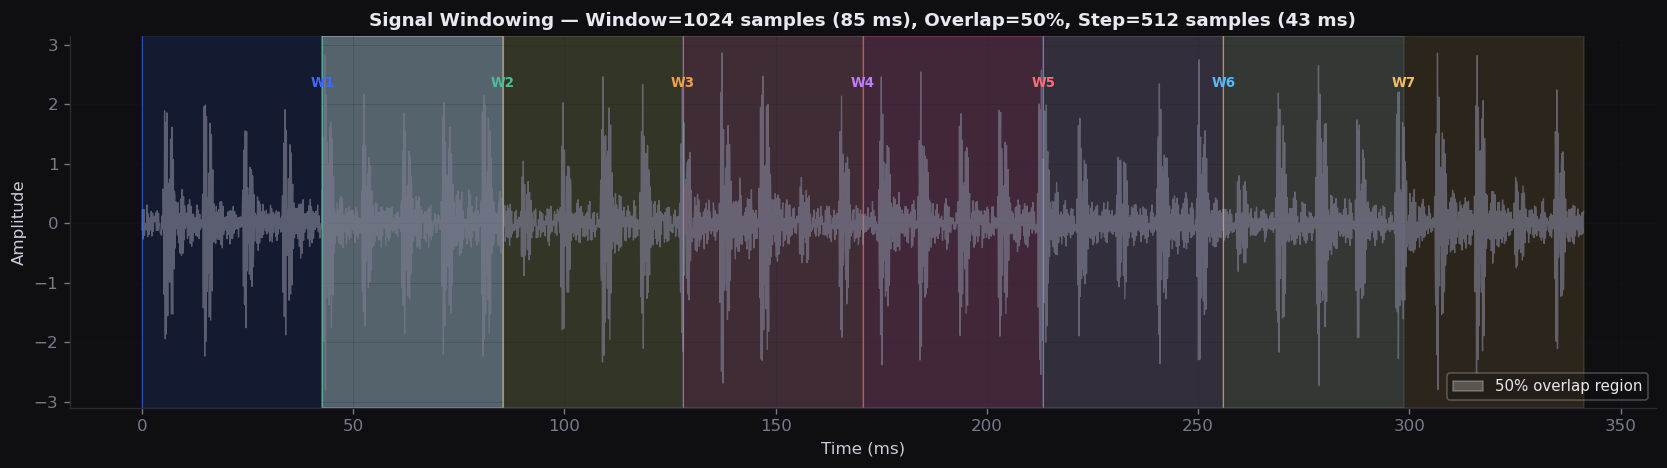

Saved → reports/10_windowing.png


In [12]:
demo_clean = next(r for r in records if r['label'] == 3)['signal_clean']
N_VIZ = WINDOW_SIZE * 4
t_viz= np.arange(N_VIZ) / FS * 1000
STEP = int(WINDOW_SIZE * (1 - OVERLAP))

fig,ax = plt.subplots(figsize=(14, 4))
ax.plot(t_viz, demo_clean[:N_VIZ], color='#7a7a8e', linewidth=0.8, alpha=0.7)

window_colors =['#3d6aff', '#4fbe97', '#f0a147', '#c17cff', '#ff6b7a', '#5ab8ff', '#f0c060']

for i in range(7):
    start_s = i * STEP
    end_s   = start_s + WINDOW_SIZE
    if end_s > N_VIZ:
        break
    t_start = start_s / FS *1000
    t_end   = end_s / FS*1000
    color   = window_colors[i % len(window_colors)]
    ax.axvspan(t_start, t_end, alpha=0.13, color=color)
    ax.axvline(t_start, color=color, linewidth=0.7, alpha=0.6)
    ypos = demo_clean[:N_VIZ].max() * 0.80
    ax.text((t_start + t_end) / 2, ypos, f'W{i+1}',
            ha='center', fontsize=8, color=color, fontweight='bold')

overlap_end = STEP /FS *1000 + WINDOW_SIZE /FS* 1000
ax.axvspan(STEP / FS *1000, WINDOW_SIZE / FS *1000,
           alpha=0.25, color='#ffffff', label=f'50% overlap region')
ax.legend(fontsize=9, framealpha=0.3)

ax.set_title(
    f'Signal Windowing — Window={WINDOW_SIZE} samples ({WINDOW_SIZE/FS*1000:.0f} ms), '
    f'Overlap={int(OVERLAP*100)}%, Step={STEP} samples ({STEP/FS*1000:.0f} ms)',
    fontsize=11, fontweight='bold')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude')
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '10_windowing.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/10_windowing.png')

> **Note on windowing plot:** The legend references a "50% overlap region"
> (grey shading) between W1 and W2. If it appears faint, the overlap zone
> is the shared region between 43ms–85ms where consecutive windows overlap.
> The key numbers are in the title: Window=1024 samples (85ms), Step=512
> samples (43ms), meaning each new window starts halfway through the previous one.

In [13]:
all_windows= []
all_labels= []

print(f'Segmenting all signals into windows...')
print(f'  {"File":<25}  {"Samples":>12}  {"Windows":>10}  {"RMS (mean window)":>18}')
print('  ' + '─' * 72)

for rec in records:
    windows = segment_signal(rec['signal_clean'], window_size=WINDOW_SIZE, overlap=OVERLAP)
    labels  = np.full(len(windows), rec['label'], dtype=int)
    win_rms = np.sqrt(np.mean(windows**2, axis=1)).mean()

    all_windows.append(windows)
    all_labels.append(labels)

    print(f"  {rec['file']:<25}  {len(rec['signal_clean']):>12,}  "
          f"{len(windows):>10,}  {win_rms:>18.4f}")

X =np.vstack(all_windows)   
y =np.concatenate(all_labels) 
print('  ' + '─' * 72)
print(f'  Total{" ":>33} {len(X):>10,}')
print()
print(f'✓ X shape : {X.shape}   (windows × samples_per_window)')
print(f'✓ y shape : {y.shape}')
print(f'✓ X dtype : {X.dtype}')
print(f'✓ X size  : {X.nbytes / 1024**2:.1f} MB')

Segmenting all signals into windows...
  File                            Samples     Windows   RMS (mean window)
  ────────────────────────────────────────────────────────────────────────
  IR_007_1.mat                    121,991         237              0.2925
  IR_014_1.mat                    121,846         236              0.1644
  IR_021_1.mat                    121,556         236              0.4414
  IR_028_1.mat                    121,351         236              0.8367
  OR_007_1.mat                    122,426         238              0.5880
  OR_021_1.mat                    121,991         237              0.5548
  ball_007_1.mat                  121,410         236              0.1389
  ball_014_1.mat                  122,136         237              0.1365
  ball_021_1.mat                  121,701         236              0.1224
  ball_028_1.mat                  121,351         236              2.0205
  normal_1.mat                    483,903         944              0.065

---
## 8. Window-Level Class Distribution

In [14]:
window_counts = Counter(y)
total_windows = len(y)

print('── Window-Level Class Distribution ─────────────────────────────────')
for label, count in sorted(window_counts.items()):
    pct = count / total_windows * 100
    bar = '█' * int(pct / 1.5)
    print(f'  {label} {get_label_name(label):<12}: '
          f'{count:>6,} windows  ({pct:5.1f}%)  {bar}')
print(f'  Total                  : {total_windows:>6,} windows')

print()
min_class = min(window_counts.values())
max_class = max(window_counts.values())
imbalance_ratio = max_class / min_class
print(f'  Imbalance ratio (max/min windows): {imbalance_ratio:.2f}x')


── Window-Level Class Distribution ─────────────────────────────────
  0 Normal      :    944 windows  ( 28.5%)  ███████████████████
  1 Inner Race  :    945 windows  ( 28.6%)  ███████████████████
  2 Ball        :    945 windows  ( 28.6%)  ███████████████████
  3 Outer Race  :    475 windows  ( 14.4%)  █████████
  Total                  :  3,309 windows

  Imbalance ratio (max/min windows): 1.99x


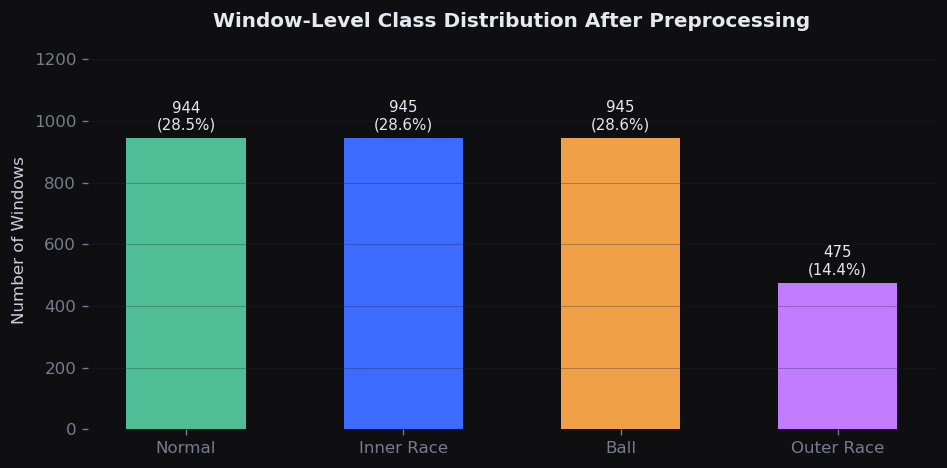

Saved → reports/11_window_distribution.png


In [15]:
classes = sorted(window_counts.keys())
counts= [window_counts[c] for c in classes]
names =[get_label_name(c) for c in classes]
colors= [CLASS_COLORS[c] for c in classes]

fig,ax = plt.subplots(figsize=(8,4))
bars = ax.bar(names, counts, color=colors, edgecolor='none', width=0.55)

for bar, count in zip(bars, counts):
    pct = count / total_windows * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total_windows * 0.005,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9, color='#e8e8f0')

ax.set_title('Window-Level Class Distribution After Preprocessing',
             fontsize=12, fontweight='bold', pad=14)
ax.set_ylabel('Number of Windows')
ax.set_ylim(0, max(counts) * 1.3)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '11_window_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/11_window_distribution.png')

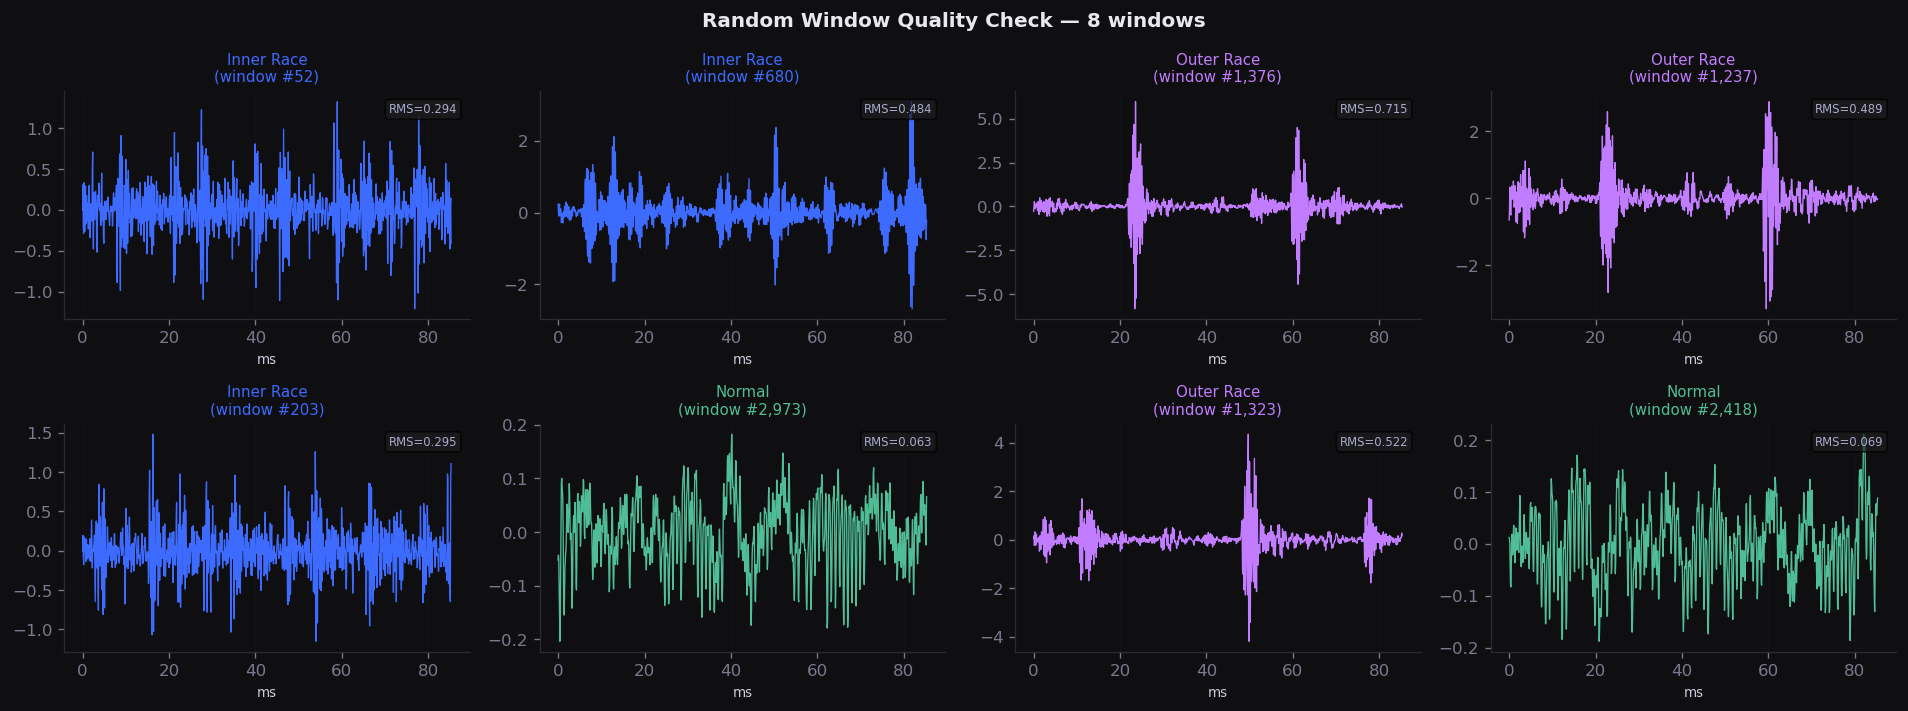

Saved → reports/12_window_quality_check.png


In [16]:
np.random.seed(RANDOM_SEED)
n_check = 8
random_idx = np.random.choice(len(X), n_check, replace=False)
t_win = np.arange(WINDOW_SIZE) / FS * 1000

fig,axes = plt.subplots(2, 4, figsize=(16, 6), sharey=False)
axes = axes.flatten()

for ax,idx in zip(axes, random_idx):
    label= y[idx]
    window = X[idx]
    color = CLASS_COLORS[label]
    rms_w  = np.sqrt(np.mean(window**2))

    ax.plot(t_win, window, color=color, linewidth=0.8)
    ax.set_title(f'{get_label_name(label)}\n(window #{idx:,})',
                 fontsize=9, color=color)
    ax.set_xlabel('ms', fontsize=8)
    ax.text(0.97, 0.95, f'RMS={rms_w:.3f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=7, color='#aaaacc',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1e1e22', alpha=0.7))
    ax.grid(True, alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Random Window Quality Check — {n_check} windows',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '12_window_quality_check.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/12_window_quality_check.png')

---
## 9. Train / Test Split (Stratified)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,              
    random_state=RANDOM_SEED
)

print('── Train / Test Split ───────────────────────────────────────────────')
print(f'  Total windows : {len(X):,}')
print(f'  Train set     : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Test set      : {len(X_test):,}   ({len(X_test)/len(X)*100:.1f}%)')
print(f'  Split seed    : {RANDOM_SEED}')
print(f'  Stratified    : yes')
print()

print('  Class distribution in each split:')
print(f'  {"Class":<14}  {"Train":>8}  {"Test":>8}  {"Train%":>8}  {"Test%":>8}')
print('  ' + '─' * 52)
for label in sorted(np.unique(y)):
    tr_count = (y_train == label).sum()
    te_count = (y_test  == label).sum()
    tr_pct   = tr_count / len(y_train) *100
    te_pct   = te_count / len(y_test) * 100
    print(f'  {get_label_name(label):<14}  {tr_count:>8,}  {te_count:>8,}  '
          f'{tr_pct:>7.1f}%  {te_pct:>7.1f}%')



── Train / Test Split ───────────────────────────────────────────────
  Total windows : 3,309
  Train set     : 2,647  (80.0%)
  Test set      : 662   (20.0%)
  Split seed    : 42
  Stratified    : yes

  Class distribution in each split:
  Class              Train      Test    Train%     Test%
  ────────────────────────────────────────────────────
  Normal               755       189     28.5%     28.5%
  Inner Race           756       189     28.6%     28.5%
  Ball                 756       189     28.6%     28.5%
  Outer Race           380        95     14.4%     14.4%


---
## 10. Save Processed Dataset

In [18]:
save_map = {
    'X_windows.npy':X,
    'y_labels.npy': y,
    'X_train.npy': X_train,
    'X_test.npy': X_test,
    'y_train.npy': y_train,
    'y_test.npy' : y_test,
}

for fname, arr in save_map.items():
    path = os.path.join(PROCESSED_DIR, fname)
    np.save(path, arr)
    size_mb = arr.nbytes / 1024**2
    print(f'  ✓ Saved {fname:<22}  shape={str(arr.shape):<20}  {size_mb:.2f} MB')

config = {
    'fs':FS,
    'window_size': WINDOW_SIZE,
    'window_ms': round(WINDOW_SIZE / FS * 1000, 2),
    'overlap': OVERLAP,
    'step_samples':int(WINDOW_SIZE * (1 - OVERLAP)),
    'cutoff_hz':CUTOFF_HZ,
    'filter_order':FILTER_ORDER,
    'normalization':'none — removed, use StandardScaler on features in notebook 03',
    'n_total_windows':len(X),
    'n_train_windows': len(X_train),
    'n_test_windows': len(X_test),
    'test_size': TEST_SIZE,
    'random_seed': RANDOM_SEED,
    'n_classes': int(len(np.unique(y))),
    'hanning_window_in_fft': True,
}

config_path = os.path.join(PROCESSED_DIR, 'preprocessing_config.csv')
pd.DataFrame([config]).to_csv(config_path, index=False)
print(f'  ✓ Saved preprocessing_config.csv')
print()
print('All files saved to:', PROCESSED_DIR)

  ✓ Saved X_windows.npy           shape=(3309, 1024)          25.85 MB
  ✓ Saved y_labels.npy            shape=(3309,)               0.03 MB
  ✓ Saved X_train.npy             shape=(2647, 1024)          20.68 MB
  ✓ Saved X_test.npy              shape=(662, 1024)           5.17 MB
  ✓ Saved y_train.npy             shape=(2647,)               0.02 MB
  ✓ Saved y_test.npy              shape=(662,)                0.01 MB
  ✓ Saved preprocessing_config.csv

All files saved to: C:\Users\My Pc\Downloads\predictive-maintenance\data\processed


---
## 11. Preprocessing Summary

**PIPELINE APPLIED (in order)**
  1. DC offset removal       — zero-mean each signal
  2. Butterworth low-pass    — cutoff 5000 Hz, order 5, zero-phase (filtfilt)
  3. Per-signal normalization — REMOVED (was erasing discriminative energy features)
  4. Windowing               — 1024 samples (85.3 ms), 50% overlap
  5. Stratified train/test split — 80/20, seed=42

**OUTPUT FILES**
  data/processed/X_windows.npy
  
  data/processed/y_labels.npy
  
  data/processed/X_train.npy
  
  data/processed/X_test.npy
  
  data/processed/y_train.npy
  
  data/processed/y_test.npy
  
  data/processed/preprocessing_config.csv

**DATASET SHAPE**
  Full dataset   : X=(3309, 1024)  y=(3309,)
  
  Training set   : X_train=(2647, 1024)  y_train=(2647,)
  
  Test set       : X_test=(662, 1024)   y_test=(662,)

**CLASS BREAKDOWN (full dataset)**
  0 Normal      :    944  (28.5%)
  
  1 Inner Race  :    945  (28.6%)
  
  2 Ball        :    945  (28.6%)
  
  3 Outer Race  :    475  (14.4%)